## EDA y Estilo pythonico

### 1) Importar el paquete

En esta sección importamos el módulo `analisis_eda`, que contiene la clase `AnalisisEDA`.  
La idea es centralizar tareas típicas de EDA (carga, limpieza básica, outliers y gráficos) en métodos reutilizables, para no repetir código en cada notebook.

Qué se logra al importar:
- Poder instanciar `AnalisisEDA(...)` y trabajar con `ad.df` como DataFrame principal.
- Estandarizar el flujo del EDA (misma estructura para distintos datasets).
- Reducir errores (por ejemplo, validación de DataFrame vacío antes de ejecutar análisis).

In [1]:
import paquete_analisis_eda_ns as mf

### 2) Cargar el Dataset

In [2]:
path = "Mall_Customers.csv"

ad = mf.AnalisisEDA(path=path, sep=",", decimal=".", index_col=None)

df = ad.df
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2.1) Vista rápida

La “vista rápida” sirve para validar que la carga fue correcta y entender el tamaño real del dataset.

In [3]:
ad.df.tail(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [4]:
ad.df.count()

CustomerID                200
Gender                    200
Age                       200
Annual Income (k$)        200
Spending Score (1-100)    200
dtype: int64

In [5]:
ad.df.shape

(200, 5)

### 3) Verificar tipos de datos

Esta sección confirma qué columnas son numéricas y cuáles categóricas, porque eso define:
- qué estadísticas se pueden calcular,
- qué gráficos tienen sentido,
- y qué transformaciones serán necesarias para modelado (por ejemplo, dummies).

In [6]:
ad.tipoDatos()

Tipos de datos por columna:

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


### 4) Eliminar columnas irrelevantes

Aquí se elimina información que no aporta al análisis o que podría “ensuciar” un modelo.

In [7]:
# En el caso de usarse descomentar.
# columnas_irrelevantes = ["col_inutil_1", "col_inutil_2"]
# ad.eliminarColumnas(columnas_irrelevantes)
#ad.df.head(3)

### 5) Renombrar columnas

Renombrar columnas mejora legibilidad y consistencia (especialmente si vas a documentar el notebook o escribir conclusiones).

Ejemplos útiles:
- Convertir nombres a español o a snake_case.
- Hacer más explícitas columnas como `Months_Inactive_12_mon` → `meses_inactivo_12m`.

In [8]:
# En el caso de usarse descomentar.
# nuevos_nombres = {"OldName": "NuevoNombre"}
# ad.renombrarColumnas(nuevos_nombres)
#ad.df.head(3)

### 6) Eliminar filas duplicadas

Los duplicados pueden inflar estadísticas y sesgar conclusiones (por ejemplo, duplicar clientes).

In [9]:
ad.eliminarDuplicados()

Se eliminaron 0 filas duplicadas. Total actual: 200 filas.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### 7) Revisar valores faltantes / nulos

Los valores faltantes suelen obligar a imputación o eliminación de filas/columnas, y afectan:
- medias y correlaciones,
- distribución de clases,
- y entrenamiento de modelos.

In [10]:
ad.valores_faltantes()

Missing values por columna:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### 7.1) Eliminar nulos

Este paso elimina filas con nulos para “limpiar” el dataset.

In [11]:
# Elimina filas con nulos (por defecto how="any")
ad.eliminarNulos()

Valores nulos totales antes: 0
Filas eliminadas por nulos: 0
Valores nulos restantes: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### 8) Convertir categóricas a dummies

La conversión a dummies (one-hot encoding) se usa principalmente para modelado, porque muchos algoritmos requieren variables numéricas.

In [12]:
# Descomentar en el caso de usarse.
# Recomendado: excluir IDs y la columna objetivo (si existe)
ad.categoricasADummies(excluir=[""])
ad.df.head(3)

Columnas categóricas convertidas a dummies: ['Gender']
Dimensiones actuales: (200, 5)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0


### 9) Resumen general

Esta sección da una tabla estadística del dataset y ayuda a detectar sesgos, rangos y escalas.

In [13]:
ad.analisisGeneral(head=5)

Dimensiones: (200, 5)

Head:

   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Gender_Male
0           1   19                  15                      39            1
1           2   21                  15                      81            1
2           3   20                  16                       6            0
3           4   23                  16                      77            0
4           5   31                  17                      40            0

Estadisticas Descriptivas (numericas)
                        count    mean        std   min    25%    50%     75%  \
CustomerID              200.0  100.50  57.879185   1.0  50.75  100.5  150.25   
Age                     200.0   38.85  13.969007  18.0  28.75   36.0   49.00   
Annual Income (k$)      200.0   60.56  26.264721  15.0  41.50   61.5   78.00   
Spending Score (1-100)  200.0   50.20  25.823522   1.0  34.75   50.0   73.00   
Gender_Male             200.0    0.44   0.497633   0.0   0.00    0.0    1.0

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0
...,...,...,...,...,...
195,196,35,120,79,0
196,197,45,126,28,0
197,198,32,126,74,1
198,199,32,137,18,1


### 10) Detectar valores atípicos (IQR)

Los outliers (atípicos) pueden ser:
- errores de medición/captura, o
- clientes extremos reales (por ejemplo, clientes “premium”).

In [14]:
ad.detectarAtipicosIQR()

Resumen de atipicos (IQR):

                  columna     q1      q3    iqr  lim_inf  lim_sup  n_atipicos  \
2      Annual Income (k$)  41.50   78.00  36.50  -13.250  132.750           2   
0              CustomerID  50.75  150.25  99.50  -98.500  299.500           0   
1                     Age  28.75   49.00  20.25   -1.625   79.375           0   
3  Spending Score (1-100)  34.75   73.00  38.25  -22.625  130.375           0   
4             Gender_Male   0.00    1.00   1.00   -1.500    2.500           0   

   pct_atipicos  
2           1.0  
0           0.0  
1           0.0  
3           0.0  
4           0.0  


,columna,q1,q3,iqr,lim_inf,lim_sup,n_atipicos,pct_atipicos
0,CustomerID,50.75,150.25,99.50,-98.500,299.500,0,0.0
1,Age,28.75,49.00,20.25,-1.625,79.375,0,0.0
2,Annual Income (k$),41.50,78.00,36.50,-13.250,132.750,2,1.0
3,Spending Score (1-100),34.75,73.00,38.25,-22.625,130.375,0,0.0
4,Gender_Male,0.00,1.00,1.00,-1.500,2.500,0,0.0


#### 10.1) Eliminar outliers por IQR

Eliminar outliers reduce ruido, pero también puede eliminar señal real.

In [15]:
# OJO: elimina filas atípicas. Úsese solo si tiene sentido para el caso.
# ad.eliminarAtipicosIQR()
# ad.df.shape

### Graficos

#### 11) Boxplot

El boxplot ayuda a ver:
- mediana,
- dispersión,
- y outliers visibles.

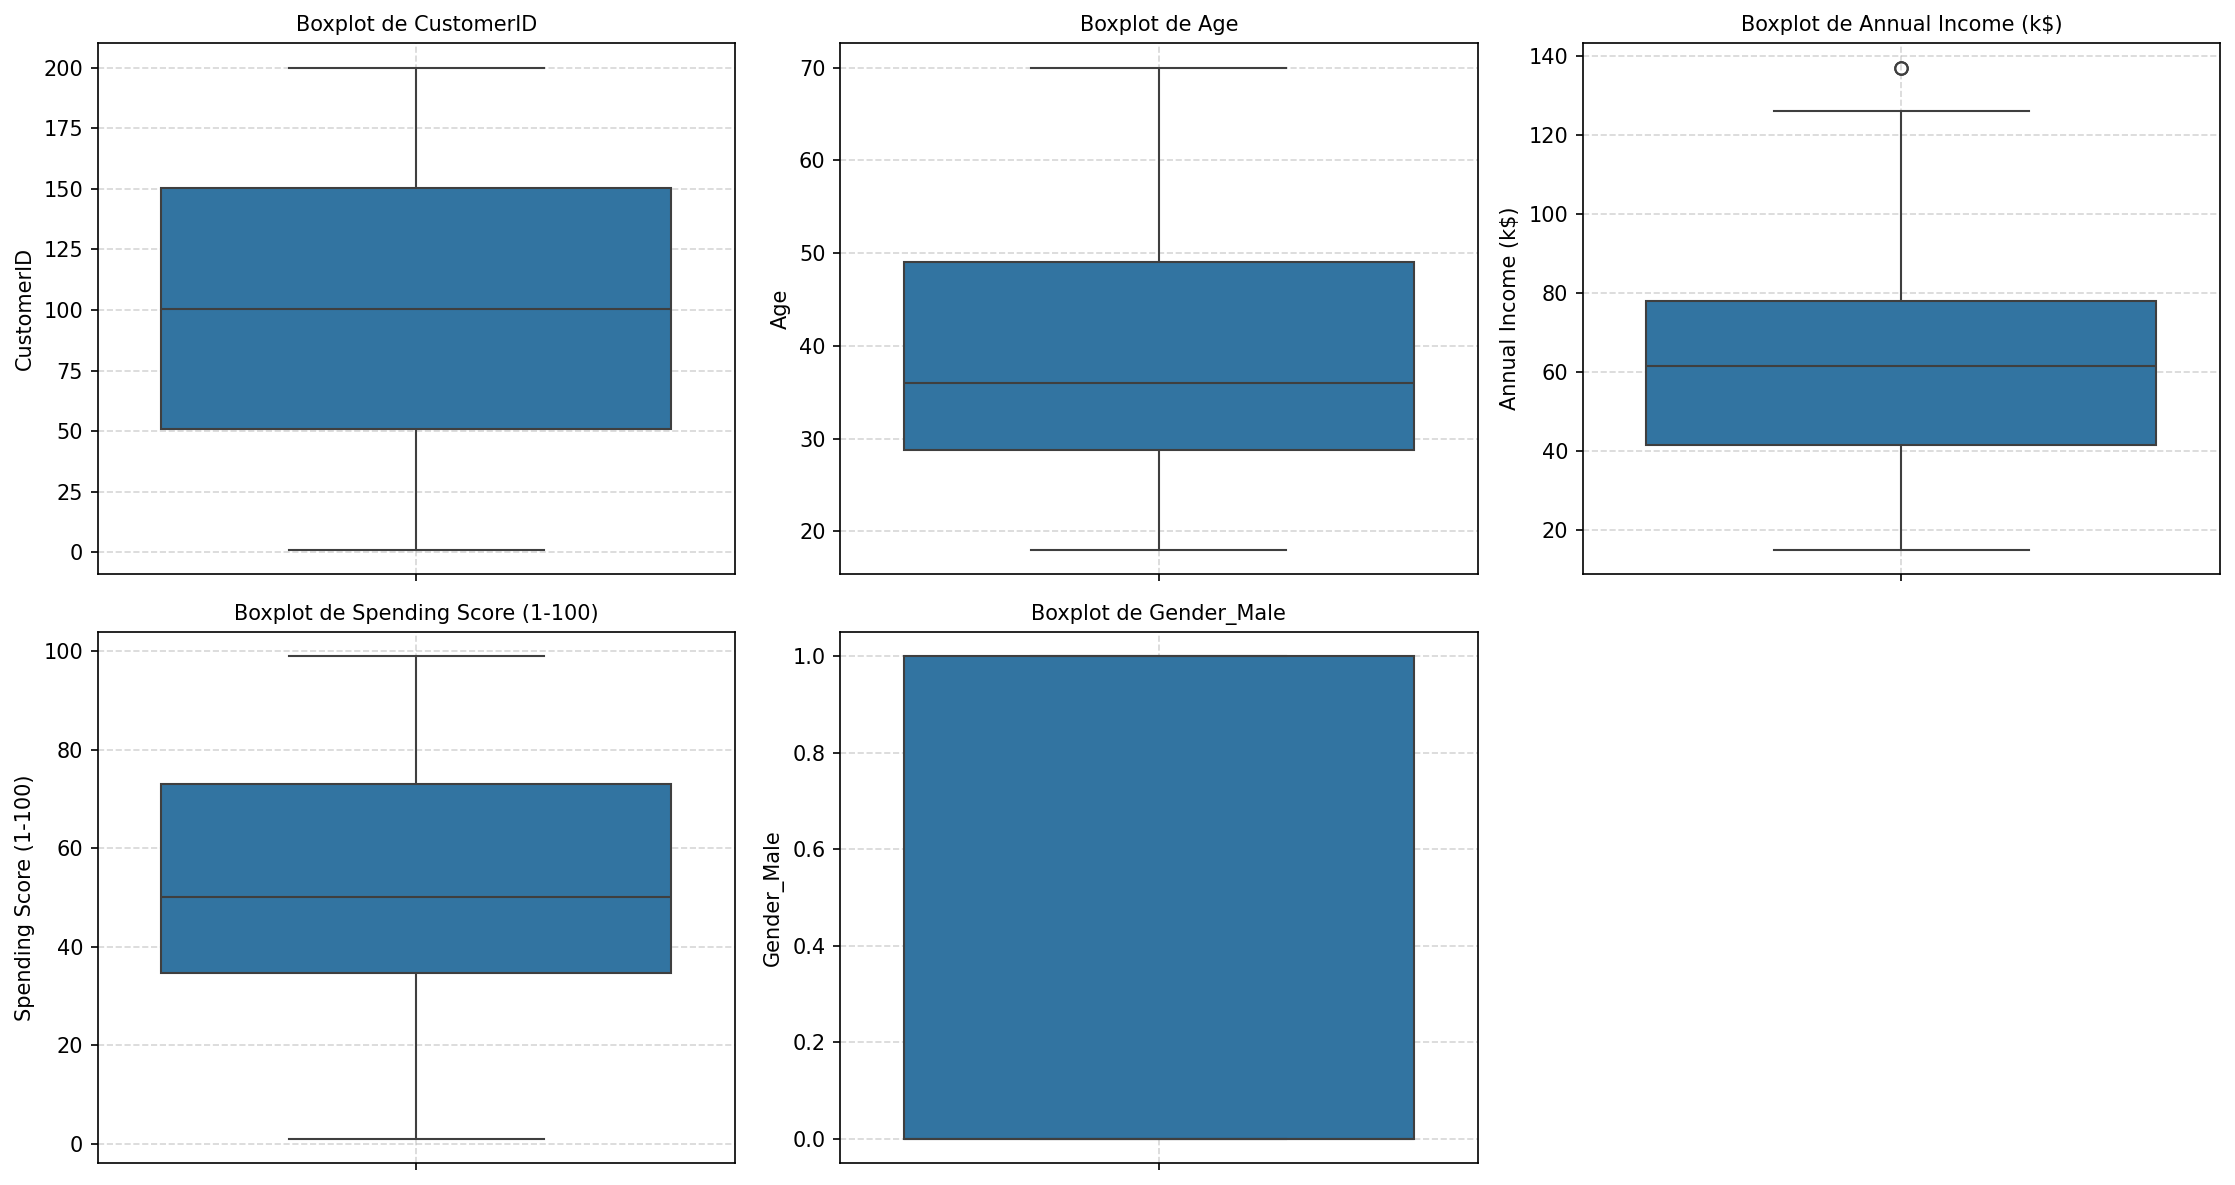

In [15]:
ad.graficoBoxplot()

#### 12) Histogramas

Los histogramas muestran la forma real de cada distribución.

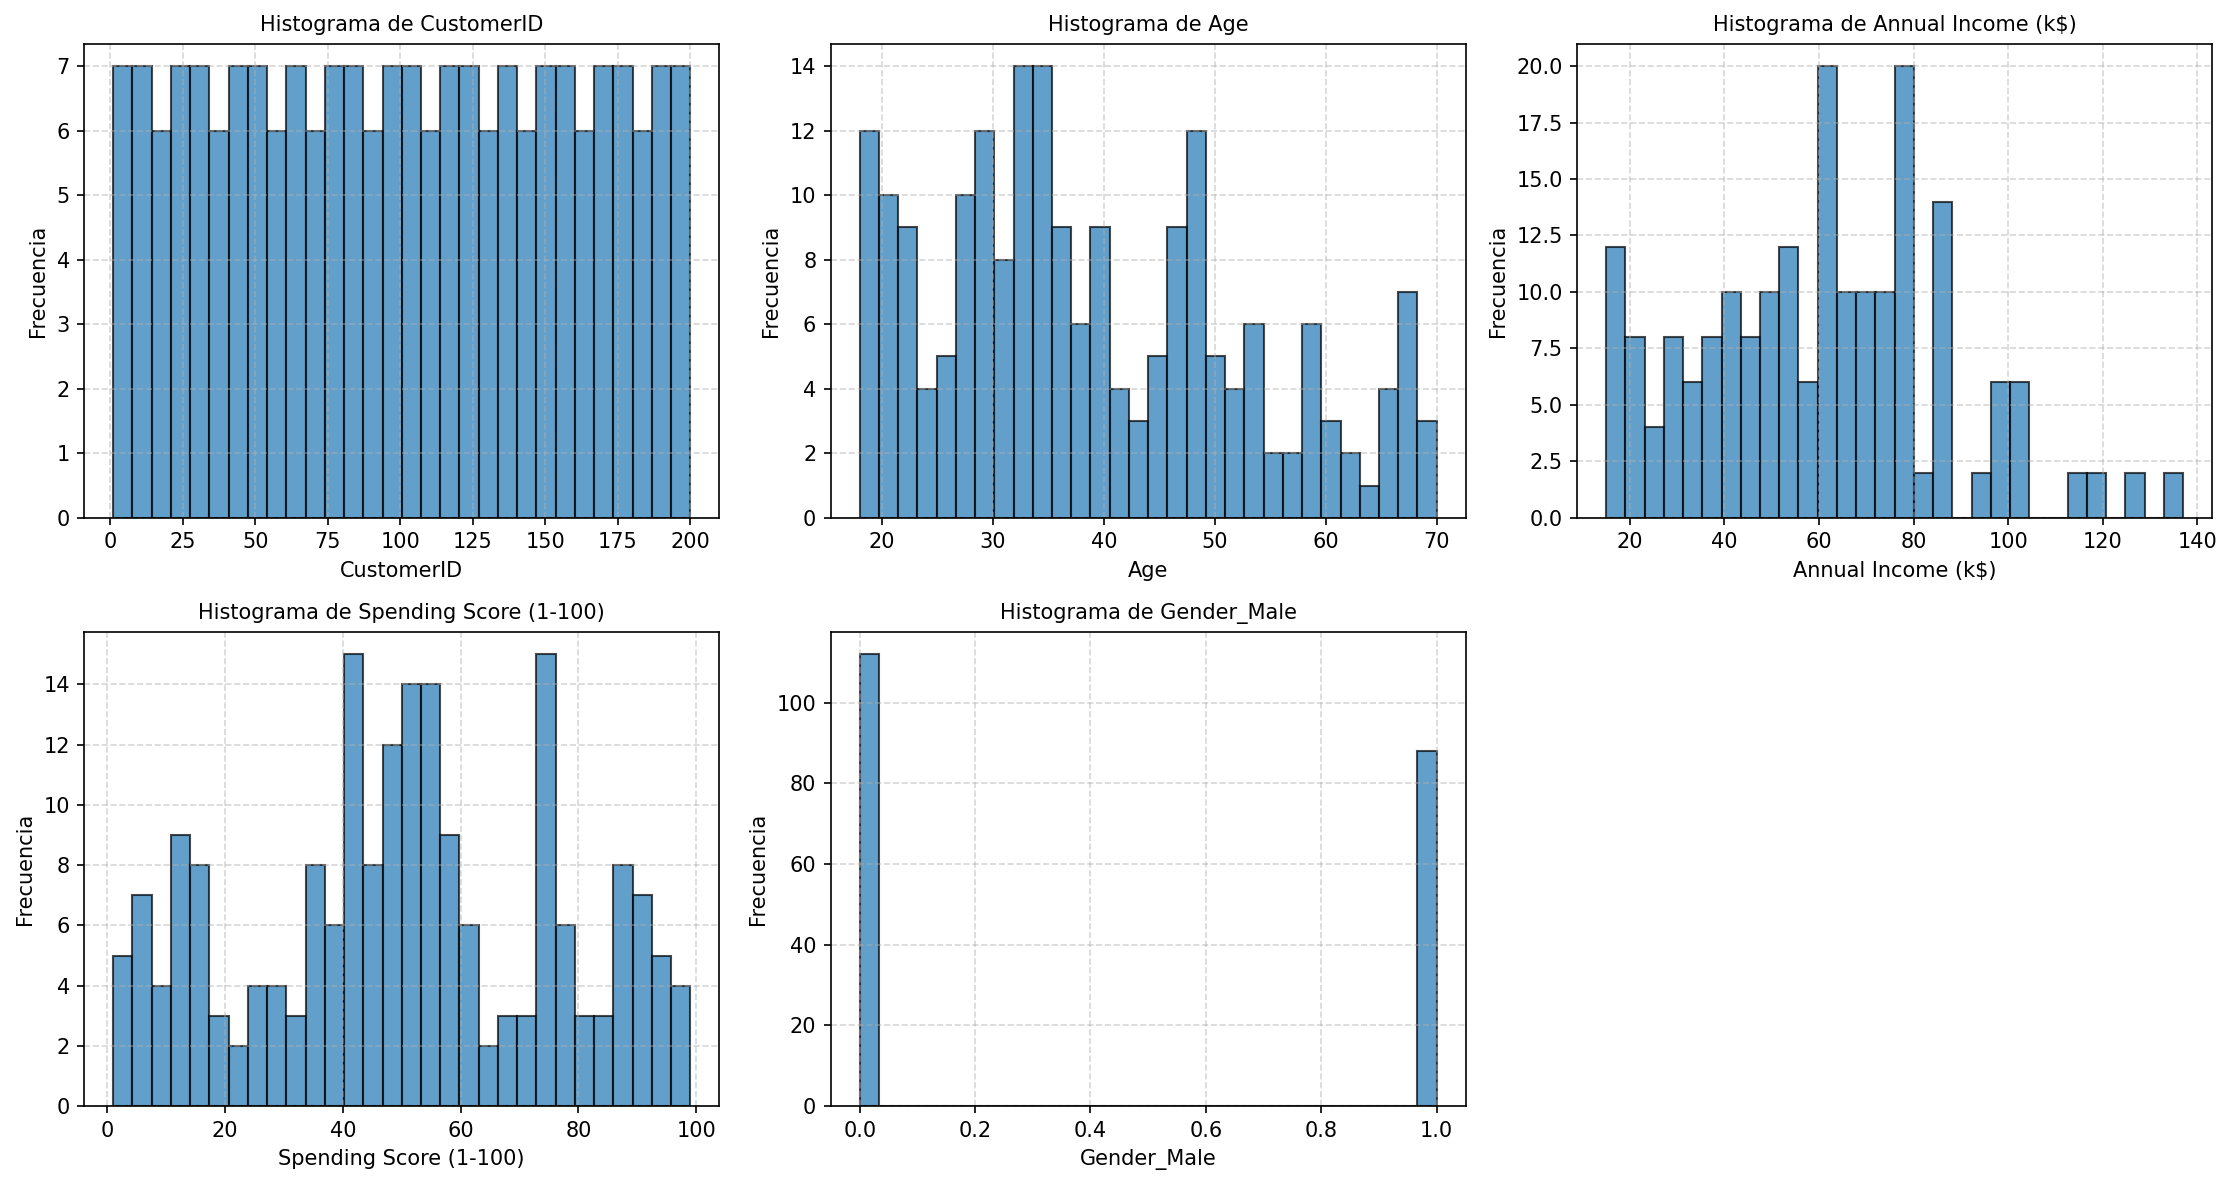

In [16]:
ad.histogramas()

#### 13) Correlación (matriz)

La correlación ayuda a identificar relaciones lineales entre variables numéricas.

In [17]:
ad.correlaciones()

Matriz de correlaciones:

                        CustomerID       Age  Annual Income (k$)  \
CustomerID                1.000000 -0.026763            0.977548   
Age                      -0.026763  1.000000           -0.012398   
Annual Income (k$)        0.977548 -0.012398            1.000000   
Spending Score (1-100)    0.013835 -0.327227            0.009903   
Gender_Male               0.057400  0.060867            0.056410   

                        Spending Score (1-100)  Gender_Male  
CustomerID                            0.013835     0.057400  
Age                                  -0.327227     0.060867  
Annual Income (k$)                    0.009903     0.056410  
Spending Score (1-100)                1.000000    -0.058109  
Gender_Male                          -0.058109     1.000000  


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
CustomerID,1.000000,-0.026763,0.977548,0.013835,0.057400
Age,-0.026763,1.000000,-0.012398,-0.327227,0.060867
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903,0.056410
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000,-0.058109
Gender_Male,0.057400,0.060867,0.056410,-0.058109,1.000000


#### 14) Correlación (heatmap)

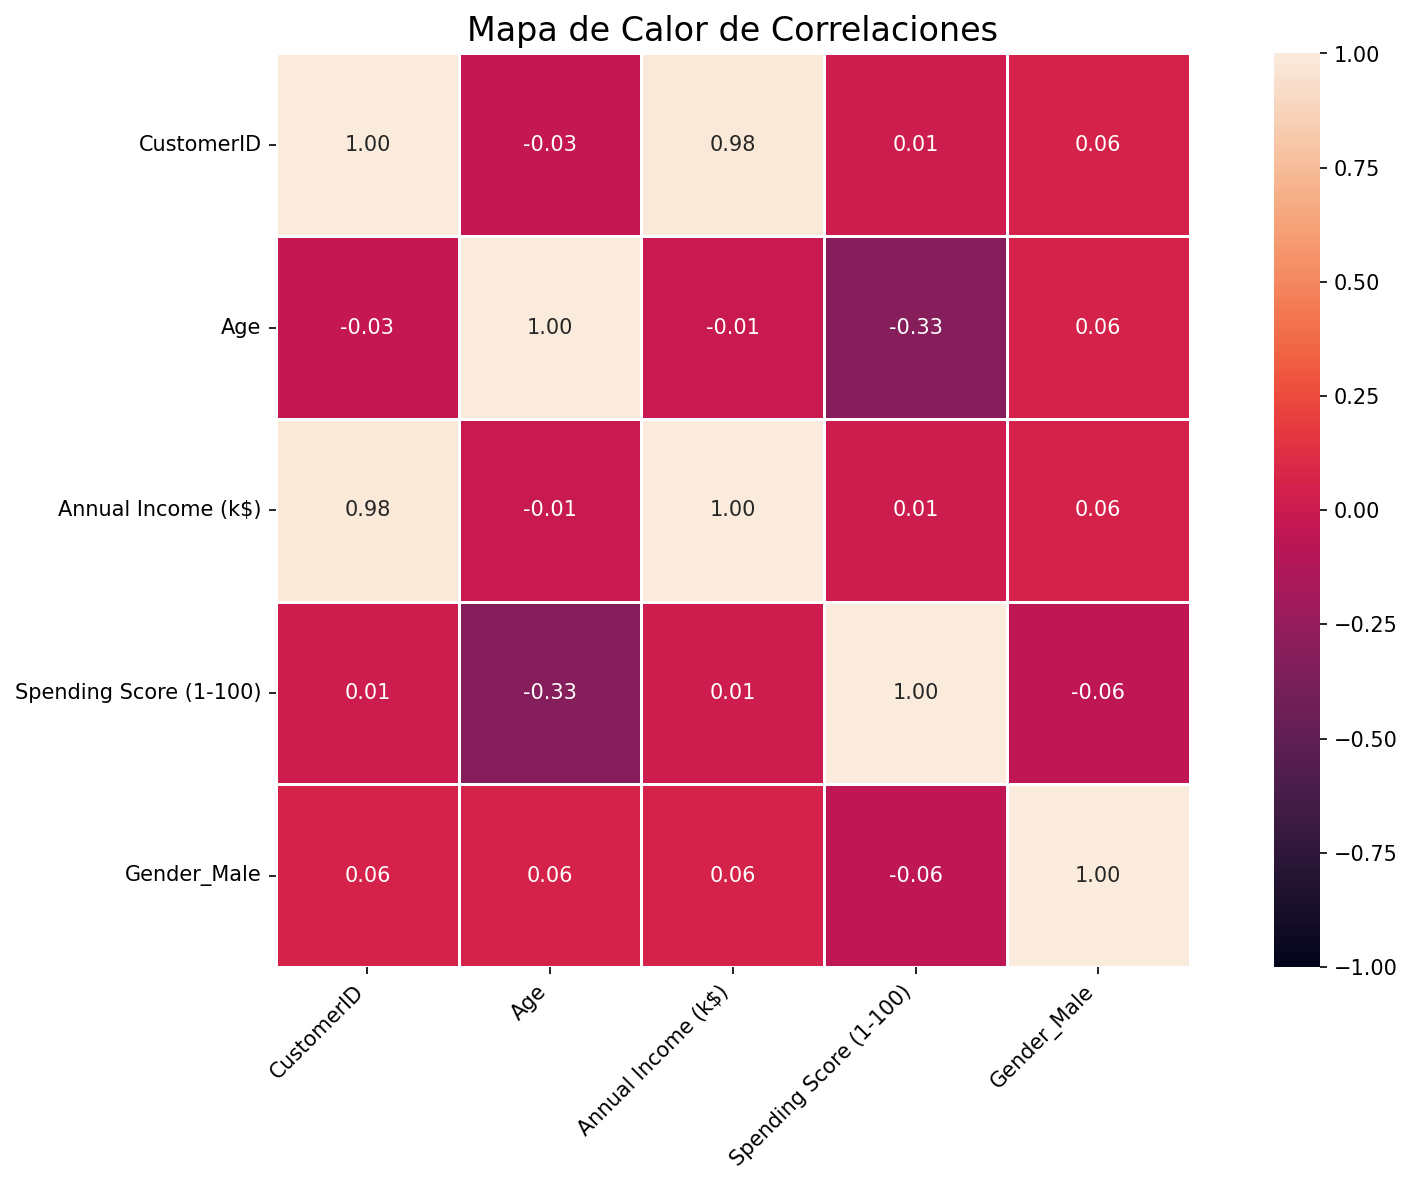

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
CustomerID,1.000000,-0.026763,0.977548,0.013835,0.057400
Age,-0.026763,1.000000,-0.012398,-0.327227,0.060867
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903,0.056410
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000,-0.058109
Gender_Male,0.057400,0.060867,0.056410,-0.058109,1.000000


In [18]:
ad.graficoCorrelacion()

#### 15) Histograma de clase/objetivo

Este gráfico sirve para ver el balance de clases del objetivo (churn).

In [19]:
# Cambia "TARGET" por tu columna objetivo real
# ad.histogramaClase("TARGET")

### 16) Modelos No Supervisados y Clustering (Front-end en Notebook)

En esta sección usamos la clase `Clustering` (que hereda de `NoSupervisado` → `AnalisisEDA`) para:

- Preparar la matriz `X` (solo numéricas y opcionalmente escaladas).
- Probar modelos **en configuración estándar** y luego **variaciones**.
- Elegir el “mejor” según métricas (silhouette / trustworthiness).
- Analizar el resultado sin escribir código de gráficos aquí (todo sale del `.py`).

In [20]:
m = mf.Clustering(path=path, sep=",", decimal=".", index_col=None)

m.df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Qué se hizo / qué se vio**
- Se importó el módulo y se creó el objeto `m`.
- `m.df` contiene el dataset cargado y listo para aplicar EDA + modelos.

### 16.1) Preparación de datos (antes de PCA/Clustering)

La idea es dejar los datos limpios y numéricos:
- quitar duplicados y nulos
- eliminar columnas irrelevantes (ej. IDs)
- convertir categóricas a dummies (si existieran)

In [21]:
# EDA mínimo
m.eliminarDuplicados()
m.eliminarNulos()

# (Opcional) si el dataset trae un ID tipo CUST_ID, es mejor eliminarlo (no aporta a clustering)
# m.eliminarColumnas(["CUST_ID"])

# (Opcional) si hay columnas categóricas relevantes, las pasamos a dummies
m.categoricasADummies()

m.analisisGeneral()  # resumen rápido del DF ya listo

Se eliminaron 0 filas duplicadas. Total actual: 200 filas.
Valores nulos totales antes: 0
Filas eliminadas por nulos: 0
Valores nulos restantes: 0
Columnas categóricas convertidas a dummies: ['Gender']
Dimensiones actuales: (200, 5)
Dimensiones: (200, 5)

Head:

   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Gender_Male
0           1   19                  15                      39            1
1           2   21                  15                      81            1
2           3   20                  16                       6            0
3           4   23                  16                      77            0
4           5   31                  17                      40            0

Estadisticas Descriptivas (numericas)
                        count    mean        std   min    25%    50%     75%  \
CustomerID              200.0  100.50  57.879185   1.0  50.75  100.5  150.25   
Age                     200.0   38.85  13.969007  18.0  28.75   36.0   49.00   
An

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0
...,...,...,...,...,...
195,196,35,120,79,0
196,197,45,126,28,0
197,198,32,126,74,1
198,199,32,137,18,1


**Qué se hizo / qué se vio**
- Se limpiaron duplicados y nulos.
- Se dejó el dataset listo para modelos (idealmente 100% numérico).
- `analisisGeneral()` te ayuda a confirmar que todo quedó consistente.

### 17) ACP / PCA (Análisis de Componentes Principales)

**Explicación simple (analogía):**
PCA es como hacer un “resumen” de muchas columnas en pocas columnas nuevas (PC1, PC2, …) que guardan la mayor parte de la información.

Aquí haremos:
1) PCA estándar (2 componentes) + gráficos
2) Variaciones (probar distintos n_componentes)
3) Elegir el “mejor” (por varianza acumulada objetivo) y analizar

Matriz X lista. shape=(200, 5) | escalar=True | dropna=True | cols=5
ACP listo. n_componentes=2 | var_exp_total=0.6665


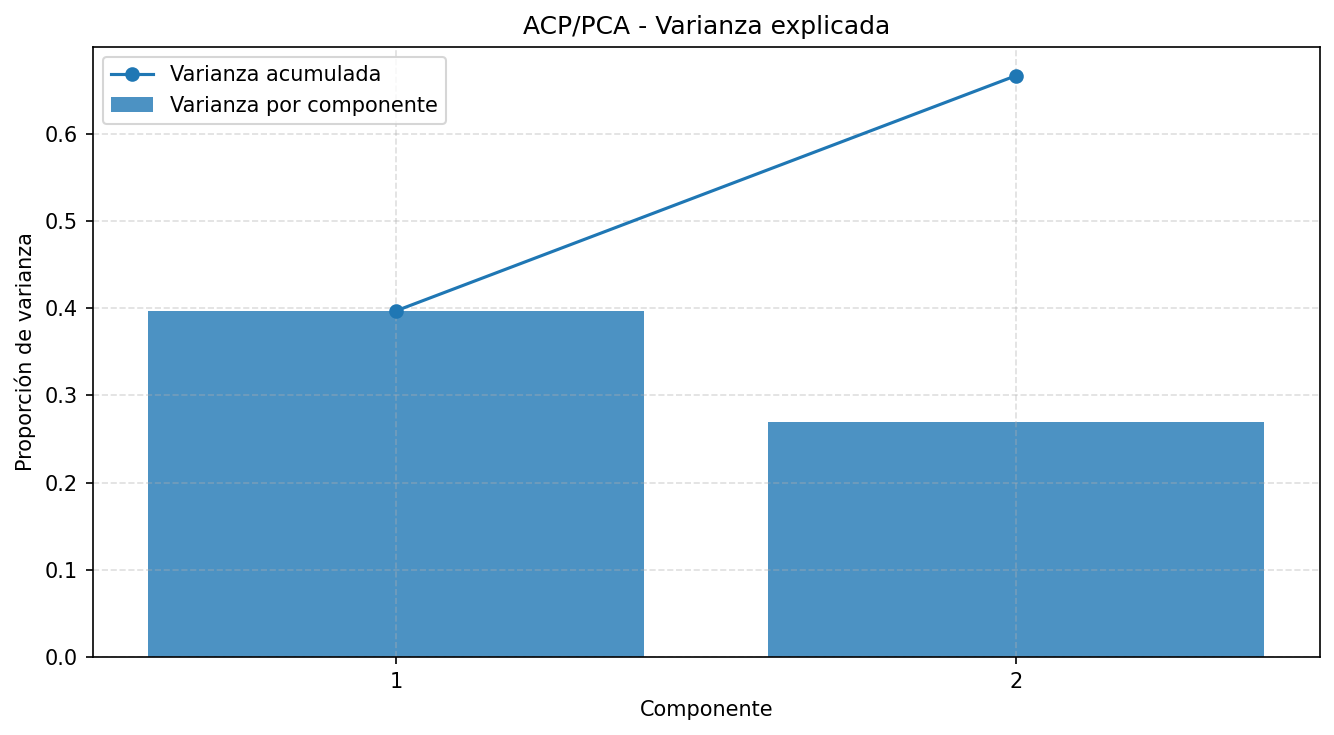

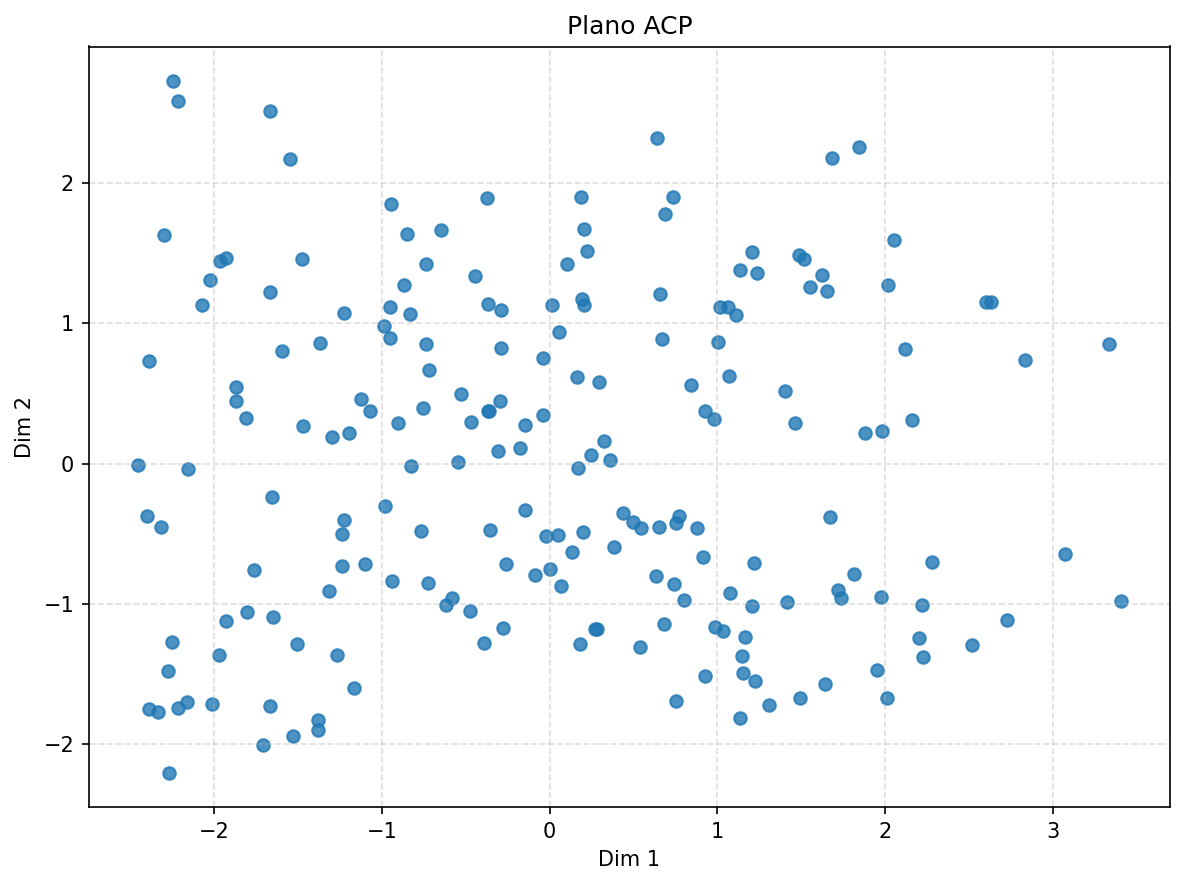

In [22]:
# 17.1 PCA estándar
res_pca = m.acp(n_componentes=2)
m.graficoVarianzaACP(res_pca)
m.plotPlanoACP(res_pca, ejes=(1,2))

**Qué se hizo / qué se vio**
- Se proyectaron los datos a 2 componentes (PC1 y PC2).
- En `graficoVarianzaACP` se observa:
  - varianza por componente
  - varianza acumulada (cuánta info retienen las PCs)
- En `plotPlanoACP` se ve si hay “nubes” o separaciones visibles.

In [23]:
# 17.2 Variaciones: probar diferentes n_componentes y sugerir el mínimo que llegue a 90% varianza
tabla_pca, sugerido_pca = m.compararACP(n_componentes_lista=(2,3,5,8,10), var_objetivo=0.90)
tabla_pca

ACP listo. n_componentes=2 | var_exp_total=0.6665
ACP listo. n_componentes=3 | var_exp_total=0.8610
ACP listo. n_componentes=5 | var_exp_total=1.0000
ACP falló para n=8: n_components=8 must be between 0 and min(n_samples, n_features)=5 with svd_solver='covariance_eigh'
ACP falló para n=10: n_components=10 must be between 0 and min(n_samples, n_features)=5 with svd_solver='covariance_eigh'
Comparación ACP:
   n_componentes  varianza_acumulada
0              2            0.666507
1              3            0.860981
2              5            1.000000
3              8                 NaN
4             10                 NaN
Sugerencia: n_componentes=5 (>= 0.9 de varianza acumulada)


,n_componentes,varianza_acumulada
0,2,0.666507
1,3,0.860981
2,5,1.000000
3,8,NaN
4,10,NaN


**Qué se hizo / qué se vio**
- Se probaron varios valores de `n_componentes`.
- `tabla_pca` muestra la varianza acumulada alcanzada.
- `sugerido_pca` te dice el mínimo n que alcanza el objetivo (ej. 0.90).

ACP listo. n_componentes=5 | var_exp_total=1.0000


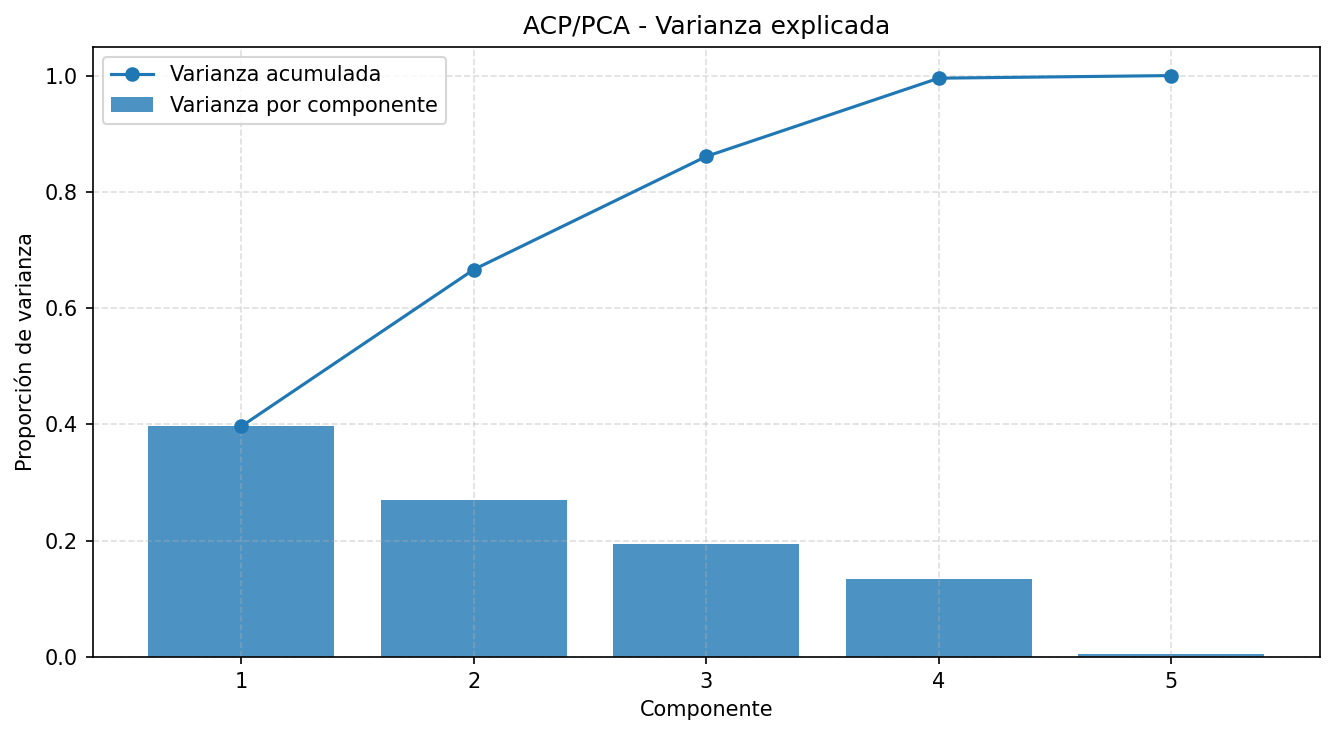

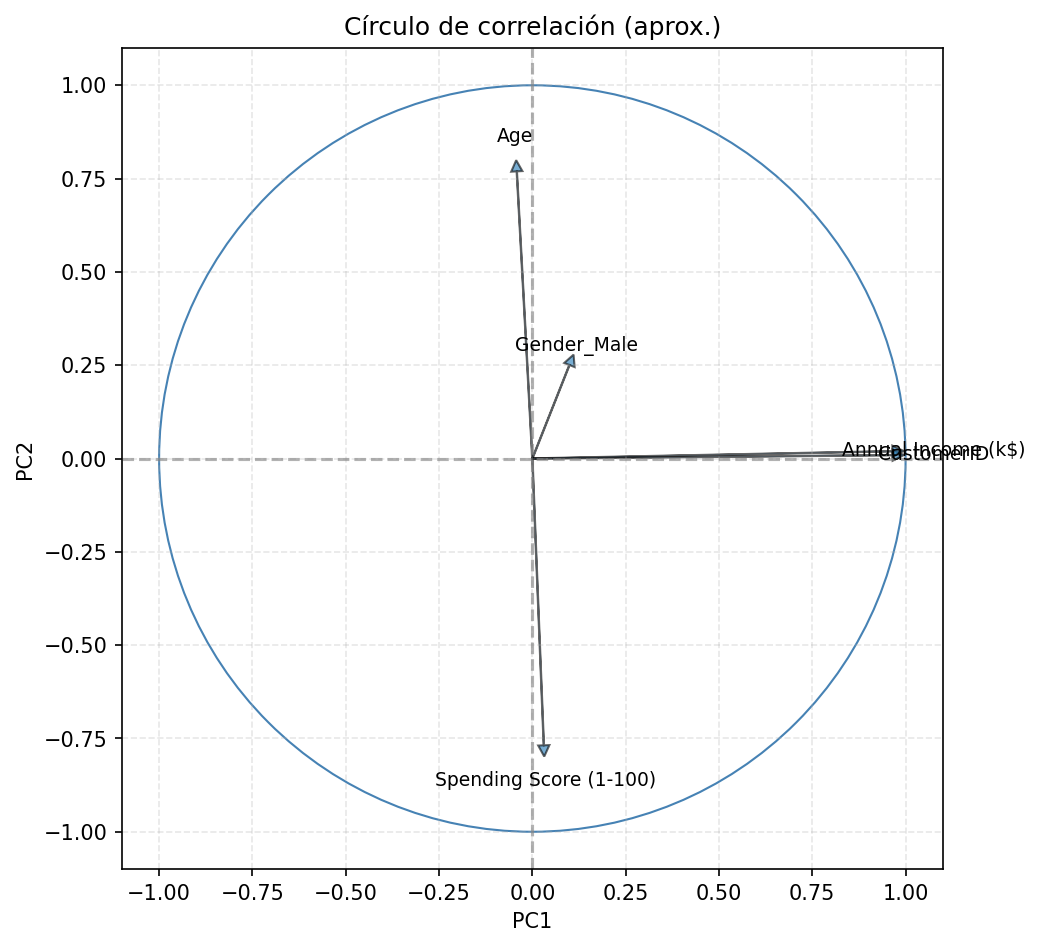

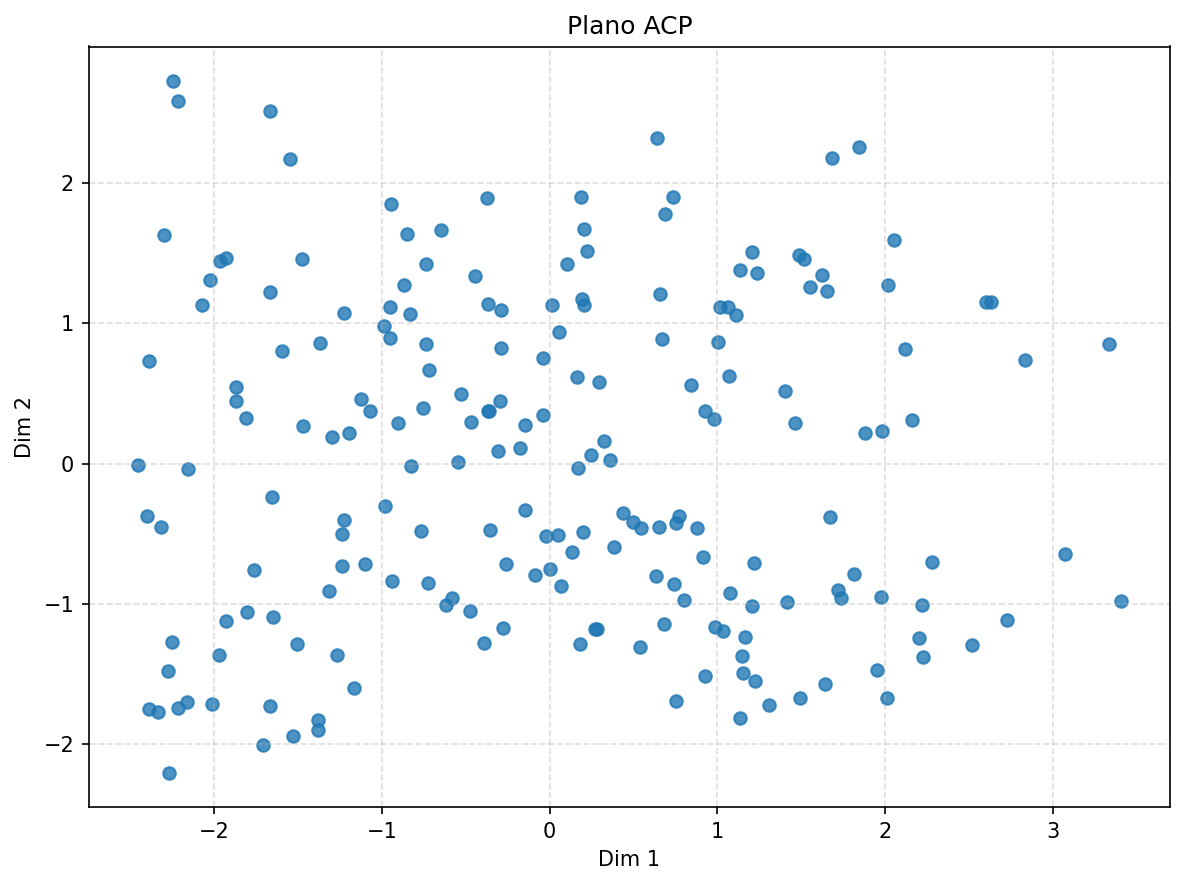

In [24]:
# 17.3 PCA "mejor" (según sugerido) + análisis con círculo de correlación
n_best = sugerido_pca if sugerido_pca is not None else 2
res_pca_best = m.acp(n_componentes=n_best)

m.graficoVarianzaACP(res_pca_best)
m.plotCirculoCorrelacionACP(res_pca_best)
m.plotPlanoACP(res_pca_best, ejes=(1,2))

**Qué se hizo / qué se vio**
- Se re-entrenó PCA con el n “recomendado”.
- El círculo de correlación ayuda a interpretar **qué variables empujan** cada componente.
- El plano principal muestra si la estructura en 2D (o PCs) se vuelve más clara.

### 18) KMeans / K-medias

**Explicación simple (analogía):**
KMeans es como poner K “mesas” y cada persona se sienta en la mesa más cercana; luego movés la mesa al centro del grupo y repites hasta estabilizar.

Aquí haremos:
1) KMeans estándar (k=3)
2) Variaciones (k=2..10) + métricas
3) Elegir el mejor k (por silhouette) y analizar

In [25]:
# 18.1 KMeans estándar
res_k_std = m.kmedias(n_clusters=3)
m.agregarClustersDF(res_k_std["labels"], "cluster_kmeans_std")
m.resumenClusters("cluster_kmeans_std")

KMeans listo. k=3 | inercia=573.84
Columna 'cluster_kmeans_std' agregada (alineada a X).
Tamaño por cluster:
cluster_kmeans_std
0.0    63
1.0    57
2.0    80
Name: count, dtype: int64

Medias numéricas por cluster:
                    CustomerID        Age  Annual Income (k$)  \
cluster_kmeans_std                                              
0.0                  73.253968  54.714286           49.492063   
1.0                  47.631579  26.105263           37.491228   
2.0                 159.625000  35.437500           85.712500   

                    Spending Score (1-100)  Gender_Male  
cluster_kmeans_std                                       
0.0                              40.571429     0.460317  
1.0                              57.912281     0.350877  
2.0                              52.287500     0.487500  


{'conteo': cluster_kmeans_std
 0.0    63
 1.0    57
 2.0    80
 Name: count, dtype: int64,
 'medias':                     CustomerID        Age  Annual Income (k$)  \
 cluster_kmeans_std                                              
 0.0                  73.253968  54.714286           49.492063   
 1.0                  47.631579  26.105263           37.491228   
 2.0                 159.625000  35.437500           85.712500   
 
                     Spending Score (1-100)  Gender_Male  
 cluster_kmeans_std                                       
 0.0                              40.571429     0.460317  
 1.0                              57.912281     0.350877  
 2.0                              52.287500     0.487500  }

**Qué se hizo / qué se vio**
- Se crearon 3 grupos (k=3) como configuración estándar.
- `resumenClusters` muestra tamaño de cada cluster y promedios por variables (para interpretarlos).

Matriz X lista. shape=(200, 6) | escalar=True | dropna=True | cols=6
Evaluación KMeans:
    k     inercia  silhouette  davies_bouldin  calinski_harabasz
0   2  768.439234    0.330360        1.274846         111.198164
1   3  573.838687    0.337920        1.166466         107.481233
2   4  465.037842    0.349712        1.205430         103.255098
3   5  399.881245    0.349916        1.114213          97.543433
4   6  344.558022    0.371018        1.138387          96.329636
5   7  302.058977    0.371214        1.035110          95.622947
6   8  262.396453    0.401003        1.010285          98.008664
7   9  235.790294    0.404386        0.963385          97.631274
8  10  211.814434    0.403882        0.903986          98.490433
Mejor k (por silhouette): 9


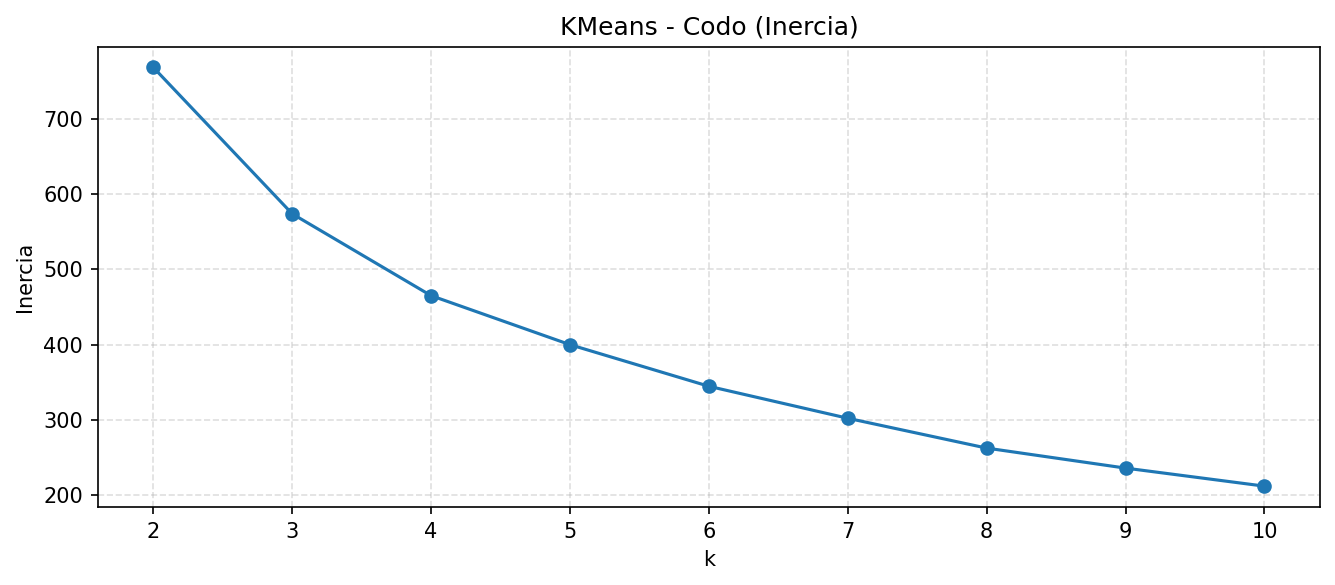

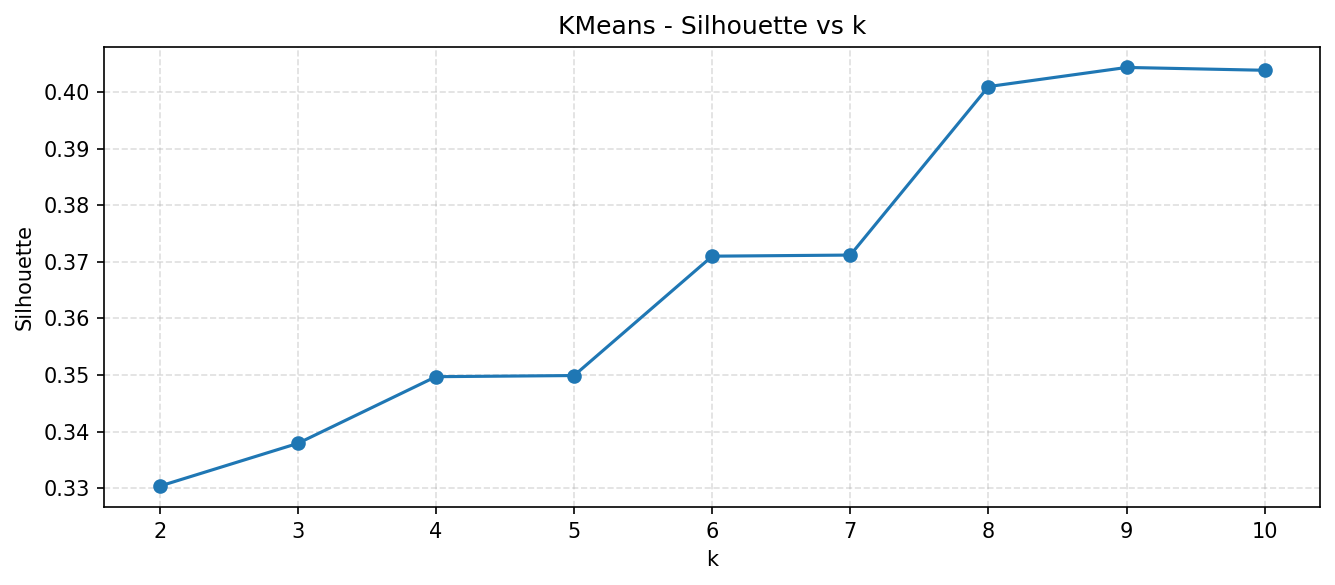

,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,2,768.439234,0.330360,1.274846,111.198164
1,3,573.838687,0.337920,1.166466,107.481233
2,4,465.037842,0.349712,1.205430,103.255098
3,5,399.881245,0.349916,1.114213,97.543433
4,6,344.558022,0.371018,1.138387,96.329636
5,7,302.058977,0.371214,1.035110,95.622947
6,8,262.396453,0.401003,1.010285,98.008664
7,9,235.790294,0.404386,0.963385,97.631274
8,10,211.814434,0.403882,0.903986,98.490433


In [26]:
# 18.2 Variaciones: buscar el mejor k
tabla_k, mejor_k = m.evaluarKmedias(k_min=2, k_max=10)
m.graficoCodoSilhouette(tabla_k)
tabla_k

**Qué se hizo / qué se vio**
- Se probó k desde 2 hasta 10.
- `tabla_k` incluye métricas (silhouette, davies-bouldin, calinski) e inercia.
- `graficoCodoSilhouette` ayuda a ver el “codo” e identificar un k razonable.
- `mejor_k` se elige por silhouette (máximo).

In [27]:
# 18.3 KMeans "mejor" + análisis
res_k_best = m.kmedias(n_clusters=mejor_k)
m.agregarClustersDF(res_k_best["labels"], "cluster_kmeans_best")
m.resumenClusters("cluster_kmeans_best")

KMeans listo. k=9 | inercia=235.79
Columna 'cluster_kmeans_best' agregada (alineada a X).
Tamaño por cluster:
cluster_kmeans_best
0.0    21
1.0    31
2.0    27
3.0    19
4.0    19
5.0    14
6.0    18
7.0    29
8.0    22
Name: count, dtype: int64

Medias numéricas por cluster:
                     CustomerID        Age  Annual Income (k$)  \
cluster_kmeans_best                                              
0.0                  153.666667  31.952381           83.857143   
1.0                   56.548387  25.741935           41.612903   
2.0                   83.555556  53.666667           54.296296   
3.0                   44.578947  24.000000           36.263158   
4.0                  161.052632  40.210526           87.315789   
5.0                   22.857143  41.214286           26.071429   
6.0                  162.777778  38.000000           86.722222   
7.0                   74.275862  57.068966           49.827586   
8.0                  161.500000  32.545455           85.272727 

{'conteo': cluster_kmeans_best
 0.0    21
 1.0    31
 2.0    27
 3.0    19
 4.0    19
 5.0    14
 6.0    18
 7.0    29
 8.0    22
 Name: count, dtype: int64,
 'medias':                      CustomerID        Age  Annual Income (k$)  \
 cluster_kmeans_best                                              
 0.0                  153.666667  31.952381           83.857143   
 1.0                   56.548387  25.741935           41.612903   
 2.0                   83.555556  53.666667           54.296296   
 3.0                   44.578947  24.000000           36.263158   
 4.0                  161.052632  40.210526           87.315789   
 5.0                   22.857143  41.214286           26.071429   
 6.0                  162.777778  38.000000           86.722222   
 7.0                   74.275862  57.068966           49.827586   
 8.0                  161.500000  32.545455           85.272727   
 
                      Spending Score (1-100)  Gender_Male  cluster_kmeans_std  
 cluster_kmea

**Qué se hizo / qué se vio**
- Se entrenó KMeans con el k “mejor”.
- En `resumenClusters` analizás:
  - qué variables suben/bajan por cluster
  - tamaños (si hay clusters muy pequeños puede indicar ruido o outliers)

### 19) HAC / Clustering Jerárquico (Aglomerativo)

**Explicación simple (analogía):**
HAC hace un “árbol familiar” de grupos: empieza con cada punto solo y va juntando los más parecidos.
El dendrograma te muestra dónde conviene “cortar” para obtener k grupos.

Aquí haremos:
1) HAC estándar (k=3, ward+euclidean)
2) Dendrograma
3) Variaciones (k/linkage/metric) + escoger mejor y analizar

In [28]:
# 19.1 HAC estándar
res_hac_std = m.hac(n_clusters=3, linkage_="ward", metric="euclidean")
m.agregarClustersDF(res_hac_std["labels"], "cluster_hac_std")
m.resumenClusters("cluster_hac_std")

Matriz X lista. shape=(200, 7) | escalar=True | dropna=True | cols=7
HAC listo. k=3 | linkage=ward | metric=euclidean | silhouette=0.2965
Columna 'cluster_hac_std' agregada (alineada a X).
Tamaño por cluster:
cluster_hac_std
0.0    80
1.0    69
2.0    51
Name: count, dtype: int64

Medias numéricas por cluster:
                 CustomerID        Age  Annual Income (k$)  \
cluster_hac_std                                              
0.0              159.625000  35.437500           85.712500   
1.0               68.333333  52.811594           47.188406   
2.0               51.274510  25.313725           39.196078   

                 Spending Score (1-100)  Gender_Male  cluster_kmeans_std  \
cluster_hac_std                                                            
0.0                           52.287500     0.487500            2.000000   
1.0                           39.130435     0.420290            0.086957   
2.0                           61.901961     0.392157            1.000000 

{'conteo': cluster_hac_std
 0.0    80
 1.0    69
 2.0    51
 Name: count, dtype: int64,
 'medias':                  CustomerID        Age  Annual Income (k$)  \
 cluster_hac_std                                              
 0.0              159.625000  35.437500           85.712500   
 1.0               68.333333  52.811594           47.188406   
 2.0               51.274510  25.313725           39.196078   
 
                  Spending Score (1-100)  Gender_Male  cluster_kmeans_std  \
 cluster_hac_std                                                            
 0.0                           52.287500     0.487500            2.000000   
 1.0                           39.130435     0.420290            0.086957   
 2.0                           61.901961     0.392157            1.000000   
 
                  cluster_kmeans_best  
 cluster_hac_std                       
 0.0                         4.500000  
 1.0                         4.666667  
 2.0                         1.823529 

**Qué se hizo / qué se vio**
- Se crearon 3 clusters jerárquicos con una configuración estándar.
- `resumenClusters` permite interpretar los grupos igual que en KMeans.

Matriz X lista. shape=(200, 8) | escalar=True | dropna=True | cols=8


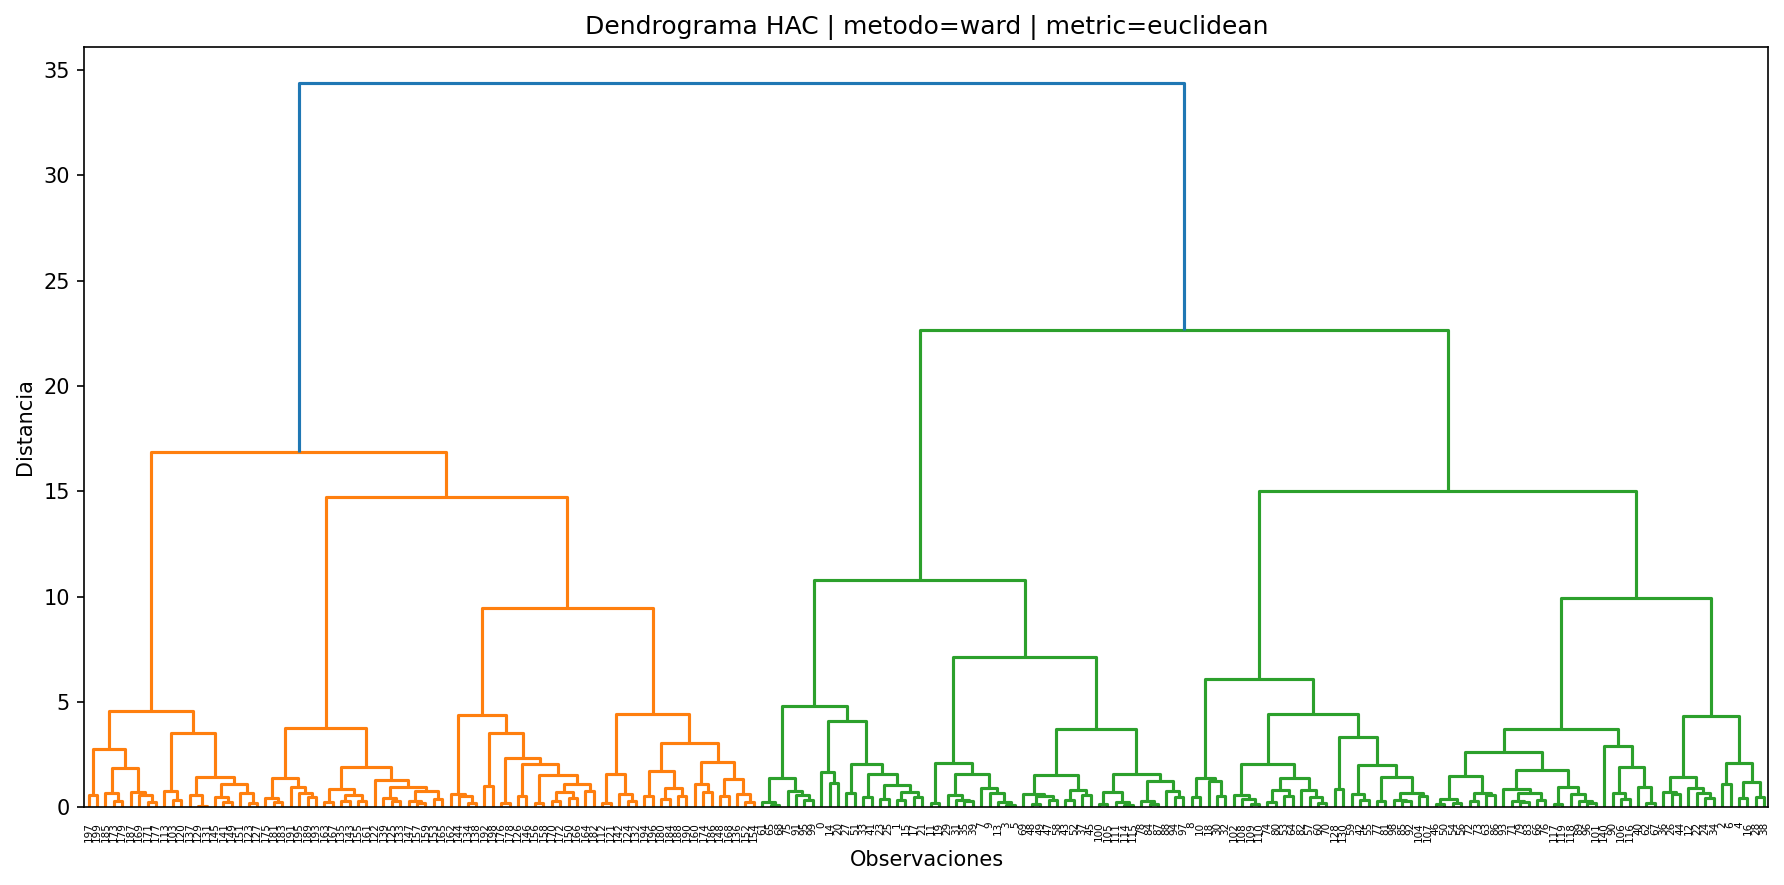

array([[1.29000000e+02, 1.31000000e+02, 7.96899476e-02, 2.00000000e+00],
       [6.50000000e+01, 6.80000000e+01, 8.86031898e-02, 2.00000000e+00],
       [3.00000000e+00, 5.00000000e+00, 9.65116918e-02, 2.00000000e+00],
       [1.14000000e+02, 1.15000000e+02, 1.07139720e-01, 2.00000000e+00],
       [1.17000000e+02, 1.19000000e+02, 1.34931699e-01, 2.00000000e+00],
       [4.80000000e+01, 4.90000000e+01, 1.44574681e-01, 2.00000000e+00],
       [8.40000000e+01, 8.70000000e+01, 1.64289767e-01, 2.00000000e+00],
       [4.60000000e+01, 5.00000000e+01, 1.71295713e-01, 2.00000000e+00],
       [1.09000000e+02, 1.10000000e+02, 1.71942672e-01, 2.00000000e+00],
       [1.00000000e+02, 1.05000000e+02, 1.72073043e-01, 2.00000000e+00],
       [9.60000000e+01, 1.01000000e+02, 1.88246523e-01, 2.00000000e+00],
       [6.20000000e+01, 6.70000000e+01, 1.95502859e-01, 2.00000000e+00],
       [1.57000000e+02, 1.59000000e+02, 1.97174718e-01, 2.00000000e+00],
       [1.23000000e+02, 1.27000000e+02, 1.99729858e

In [29]:
# 19.2 Dendrograma (visualizar el árbol)
m.dendrogramaHAC(metodo="ward", metric="euclidean", p=25)

**Qué se hizo / qué se vio**
- El dendrograma muestra cómo se van uniendo los grupos.
- Un “salto grande” en las uniones suele sugerir un buen punto de corte (k razonable).

In [30]:
# 19.3 Variaciones: elegir mejor configuración (por silhouette)
tabla_hac, mejor_hac = m.evaluarHAC(n_clusters_lista=(2,3,4,5))
tabla_hac

HAC listo. k=2 | linkage=ward | metric=euclidean | silhouette=0.3561
linkage='ward' requiere metric='euclidean'. Se ajusta metric='euclidean'.
HAC listo. k=2 | linkage=ward | metric=euclidean | silhouette=0.3561
HAC listo. k=2 | linkage=complete | metric=euclidean | silhouette=0.3561
HAC listo. k=2 | linkage=complete | metric=manhattan | silhouette=0.3561
HAC listo. k=2 | linkage=average | metric=euclidean | silhouette=0.3561
HAC listo. k=2 | linkage=average | metric=manhattan | silhouette=0.3561
HAC listo. k=3 | linkage=ward | metric=euclidean | silhouette=0.3620
linkage='ward' requiere metric='euclidean'. Se ajusta metric='euclidean'.
HAC listo. k=3 | linkage=ward | metric=euclidean | silhouette=0.3620
HAC listo. k=3 | linkage=complete | metric=euclidean | silhouette=0.3537
HAC listo. k=3 | linkage=complete | metric=manhattan | silhouette=0.3347
HAC listo. k=3 | linkage=average | metric=euclidean | silhouette=0.3620
HAC listo. k=3 | linkage=average | metric=manhattan | silhouette=0.3

,k,linkage,metric,silhouette,davies_bouldin,calinski_harabasz
0,5,average,euclidean,0.423997,0.966339,106.729807
1,5,average,manhattan,0.406139,0.997694,107.898454
2,5,ward,euclidean,0.406139,0.997694,107.898454
3,5,ward,euclidean,0.406139,0.997694,107.898454
4,4,average,euclidean,0.384305,1.062638,105.948477
5,4,average,manhattan,0.384305,1.062638,105.948477
6,4,ward,euclidean,0.384305,1.062638,105.948477
7,4,ward,euclidean,0.384305,1.062638,105.948477
8,3,average,euclidean,0.361987,1.126876,111.019733
9,3,average,manhattan,0.361987,1.126876,111.019733


**Qué se hizo / qué se vio**
- Se probaron combinaciones de:
  - cantidad de clusters (k)
  - tipo de enlace (linkage)
  - métrica de distancia (metric)
- `mejor_hac` es la primera fila (mejor silhouette).

In [31]:
# 19.4 HAC "mejor" + análisis
res_hac_best = m.hac(
    n_clusters=int(mejor_hac["k"]),
    linkage_=mejor_hac["linkage"],
    metric=mejor_hac["metric"]
)
m.agregarClustersDF(res_hac_best["labels"], "cluster_hac_best")
m.resumenClusters("cluster_hac_best")

HAC listo. k=5 | linkage=average | metric=euclidean | silhouette=0.4240
Columna 'cluster_hac_best' agregada (alineada a X).
Tamaño por cluster:
cluster_hac_best
0.0    69
1.0    37
2.0    51
3.0    21
4.0    22
Name: count, dtype: int64

Medias numéricas por cluster:
                  CustomerID        Age  Annual Income (k$)  \
cluster_hac_best                                              
0.0                68.333333  52.811594           47.188406   
1.0               161.891892  39.135135           87.027027   
2.0                51.274510  25.313725           39.196078   
3.0               153.666667  31.952381           83.857143   
4.0               161.500000  32.545455           85.272727   

                  Spending Score (1-100)  Gender_Male  cluster_kmeans_std  \
cluster_hac_best                                                            
0.0                            39.130435     0.420290            0.086957   
1.0                            20.675676     0.486486      

{'conteo': cluster_hac_best
 0.0    69
 1.0    37
 2.0    51
 3.0    21
 4.0    22
 Name: count, dtype: int64,
 'medias':                   CustomerID        Age  Annual Income (k$)  \
 cluster_hac_best                                              
 0.0                68.333333  52.811594           47.188406   
 1.0               161.891892  39.135135           87.027027   
 2.0                51.274510  25.313725           39.196078   
 3.0               153.666667  31.952381           83.857143   
 4.0               161.500000  32.545455           85.272727   
 
                   Spending Score (1-100)  Gender_Male  cluster_kmeans_std  \
 cluster_hac_best                                                            
 0.0                            39.130435     0.420290            0.086957   
 1.0                            20.675676     0.486486            2.000000   
 2.0                            61.901961     0.392157            1.000000   
 3.0                            78.3333

**Qué se hizo / qué se vio**
- Se entrenó HAC con la configuración “mejor”.
- Compará `cluster_hac_best` vs `cluster_kmeans_best`:
  - ¿son grupos parecidos?
  - ¿cuál separa mejor (métricas) y se interpreta más claro?

### 20) t-SNE (Reducción dimensional para visualización)

**Explicación simple (analogía):**
t-SNE es una “lupa” que intenta poner los datos en 2D para que los vecinos cercanos sigan cerca.
No es clustering en sí; sirve para **visualizar** si hay grupos.

Aquí haremos:
1) t-SNE estándar
2) Variaciones (perplexity / iteraciones) + seleccionar el mejor por trustworthiness
3) Graficar y analizar (coloreado por KMeans)

Matriz X lista. shape=(200, 9) | escalar=True | dropna=True | cols=9
t-SNE listo. perplexity=30 | max_iter=1000 | shape=(200, 2)


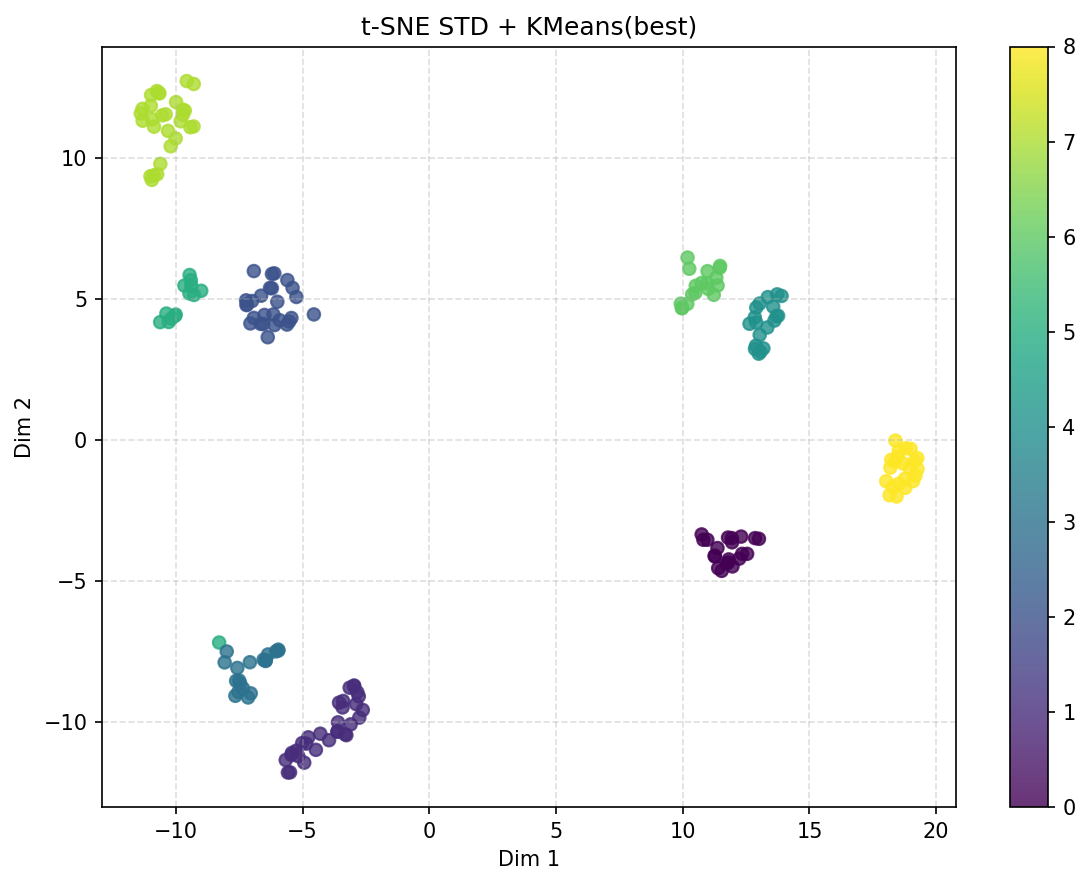

Trustworthiness (n_neighbors=5): 0.9984


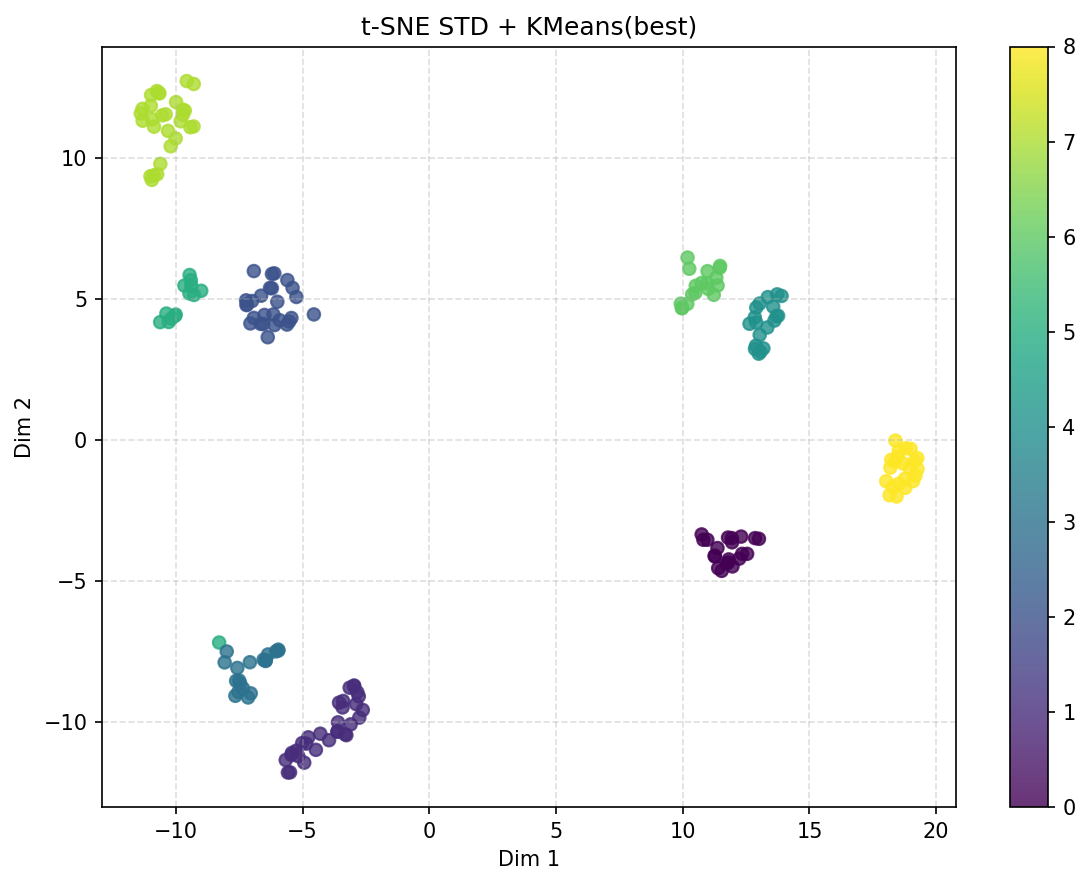

Trustworthiness (n_neighbors=5): 0.9984


0.9984114583333333

In [32]:
# 20.1 t-SNE estándar
res_tsne_std = m.tsne(perplexity=30, max_iter=1000)

m.plotEmbedding(res_tsne_std["embedding"], hue="cluster_kmeans_best", titulo="t-SNE STD + KMeans(best)")
m.evaluarTrustworthiness(res_tsne_std["embedding"])
m.plotEmbedding(res_tsne_std["embedding"], hue="cluster_kmeans_best", titulo="t-SNE STD + KMeans(best)")
m.evaluarTrustworthiness(res_tsne_std["embedding"])

**Qué se hizo / qué se vio**
- Se creó un mapa 2D con t-SNE.
- Se coloreó por el cluster de KMeans(best) para ver si el mapa separa bien los grupos.
- `trustworthiness` mide qué tan fiel es el “mapa” a los vecinos reales (más alto = mejor).

In [33]:
# 20.2 Variaciones: comparar configs y escoger la mejor por trustworthiness
tabla_tsne = m.compararTSNE([
    {"perplexity": 20, "max_iter": 1000},
    {"perplexity": 40, "max_iter": 1500},
    {"perplexity": 60, "max_iter": 1500},
])
tabla_tsne

t-SNE listo. perplexity=20 | max_iter=1000 | shape=(200, 2)
Trustworthiness (n_neighbors=5): 0.9985
t-SNE listo. perplexity=40 | max_iter=1500 | shape=(200, 2)
Trustworthiness (n_neighbors=5): 0.9980
t-SNE listo. perplexity=60 | max_iter=1500 | shape=(200, 2)
Trustworthiness (n_neighbors=5): 0.9973
Comparación t-SNE:
   perplexity  max_iter  trustworthiness
0          20      1000         0.998542
1          40      1500         0.997995
2          60      1500         0.997266


,perplexity,max_iter,trustworthiness
0,20,1000,0.998542
1,40,1500,0.997995
2,60,1500,0.997266


**Qué se hizo / qué se vio**
- Se probaron varias combinaciones.
- `tabla_tsne` queda ordenada por trustworthiness (mejor arriba).

t-SNE listo. perplexity=20.0 | max_iter=1000 | shape=(200, 2)


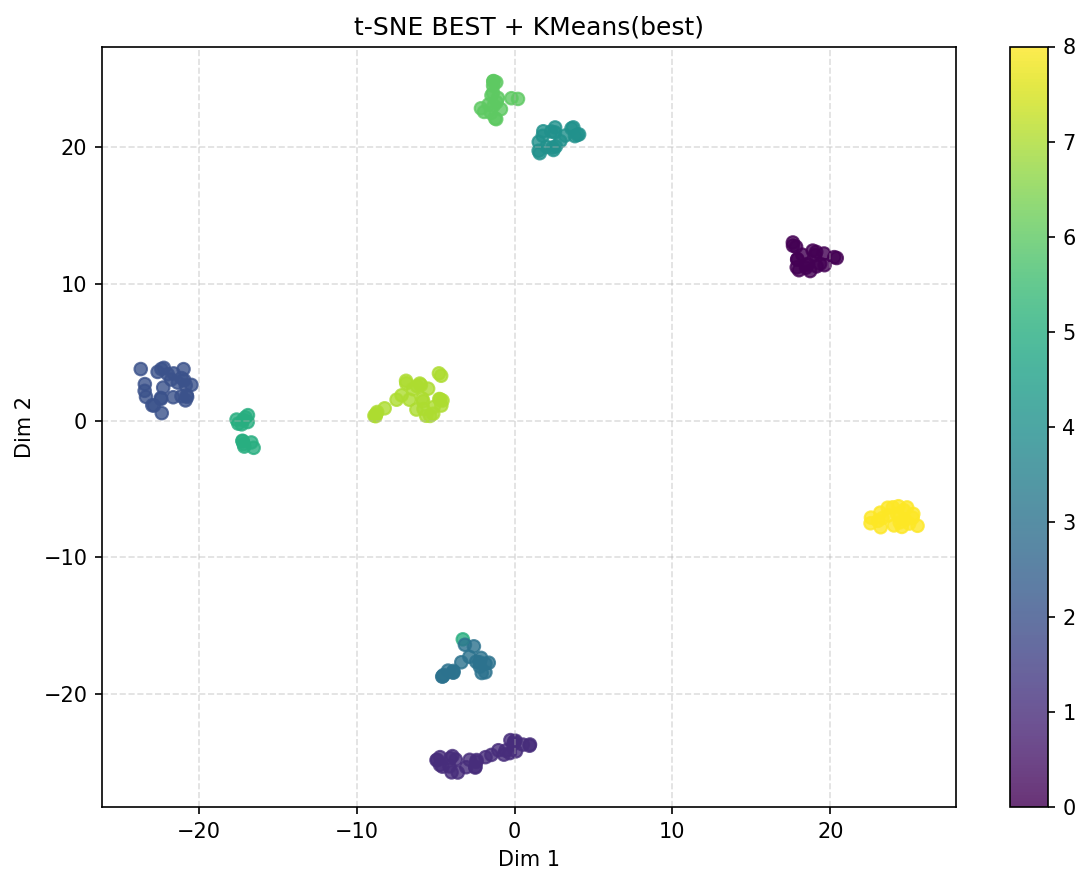

Trustworthiness (n_neighbors=5): 0.9985


0.9985416666666667

In [39]:
# 20.3 t-SNE "mejor" + análisis
best_cfg = tabla_tsne.iloc[0].to_dict()

res_tsne_best = m.tsne(perplexity=float(best_cfg["perplexity"]), max_iter=int(best_cfg["max_iter"]))
m.plotEmbedding(res_tsne_best["embedding"], hue="cluster_kmeans_best", titulo="t-SNE BEST + KMeans(best)")
m.evaluarTrustworthiness(res_tsne_best["embedding"])

**Qué se hizo / qué se vio**
- Se corrió t-SNE con la mejor configuración encontrada.
- El gráfico final (coloreado) se usa como evidencia visual de separación de grupos.

### 21) UMAP (Reducción dimensional moderna)

**Explicación simple (analogía):**
UMAP también hace un “mapa 2D”, parecido a t-SNE, pero suele ser más rápido y a veces conserva mejor la estructura global.

Aquí haremos:
1) UMAP estándar
2) Variaciones (n_neighbors / min_dist) + seleccionar el mejor por trustworthiness
3) Graficar y analizar (coloreado por KMeans)

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP listo. n_neighbors=15 | min_dist=0.1 | shape=(200, 2)


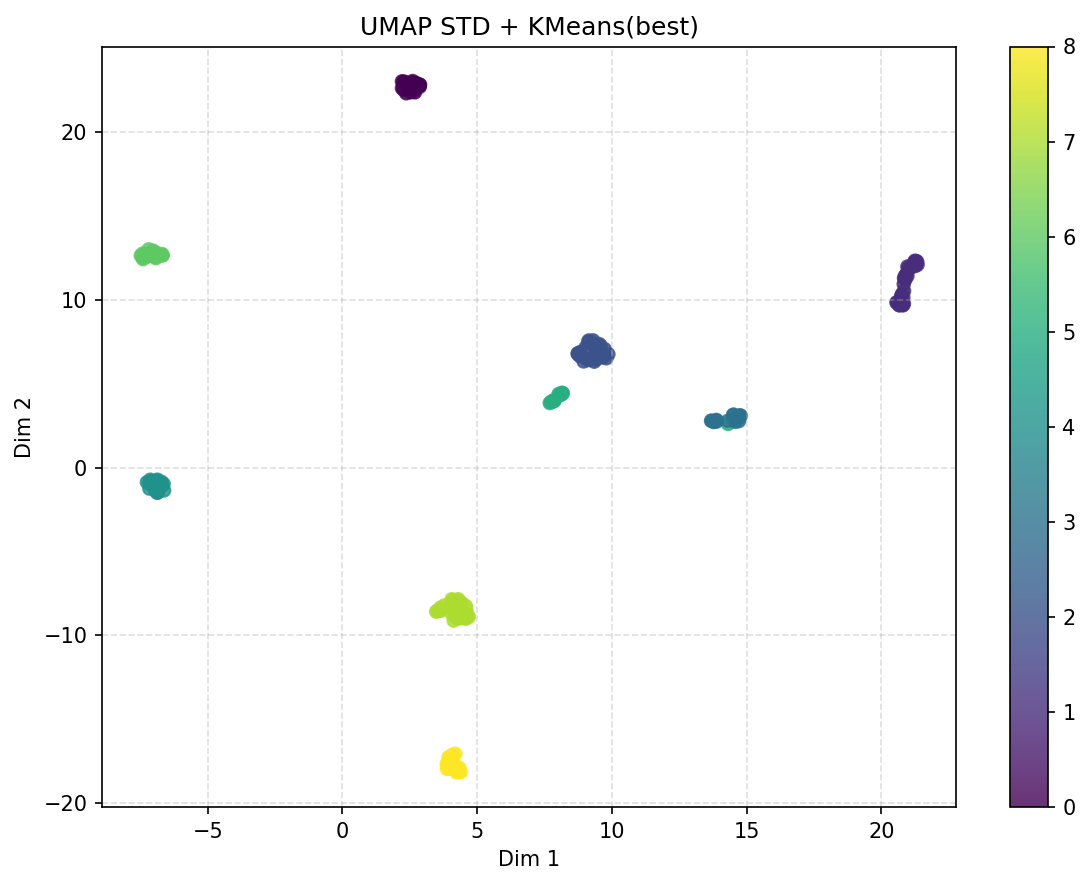

Trustworthiness (n_neighbors=5): 0.9936


0.9935833333333334

In [40]:
# 21.1 UMAP estándar
res_umap_std = m.umap(n_neighbors=15, min_dist=0.1)
m.plotEmbedding(res_umap_std["embedding"], hue="cluster_kmeans_best", titulo="UMAP STD + KMeans(best)")
m.evaluarTrustworthiness(res_umap_std["embedding"])

**Qué se hizo / qué se vio**
- UMAP genera un embedding 2D.
- Colorear por clusters ayuda a ver si UMAP “separa” grupos visualmente.
- `trustworthiness` evalúa fidelidad del embedding.

In [41]:
# 21.2 Variaciones UMAP
tabla_umap = m.compararUMAP([
    {"n_neighbors": 10, "min_dist": 0.10, "metric": "euclidean"},
    {"n_neighbors": 15, "min_dist": 0.10, "metric": "euclidean"},
    {"n_neighbors": 30, "min_dist": 0.05, "metric": "euclidean"},
])
tabla_umap

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP listo. n_neighbors=10 | min_dist=0.1 | shape=(200, 2)
Trustworthiness (n_neighbors=5): 0.9946
UMAP listo. n_neighbors=15 | min_dist=0.1 | shape=(200, 2)
Trustworthiness (n_neighbors=5): 0.9936


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP listo. n_neighbors=30 | min_dist=0.05 | shape=(200, 2)
Trustworthiness (n_neighbors=5): 0.9921
Comparación UMAP:
   n_neighbors  min_dist     metric  trustworthiness
0           10      0.10  euclidean         0.994583
1           15      0.10  euclidean         0.993583
2           30      0.05  euclidean         0.992115


,n_neighbors,min_dist,metric,trustworthiness
0,10,0.10,euclidean,0.994583
1,15,0.10,euclidean,0.993583
2,30,0.05,euclidean,0.992115


**Qué se hizo / qué se vio**
- Se probaron configuraciones distintas:
  - `n_neighbors`: tamaño del vecindario que UMAP intenta preservar
  - `min_dist`: qué tan “pegados” quedan los puntos
- La tabla queda ordenada por trustworthiness (mejor arriba).

UMAP listo. n_neighbors=10 | min_dist=0.1 | shape=(200, 2)


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


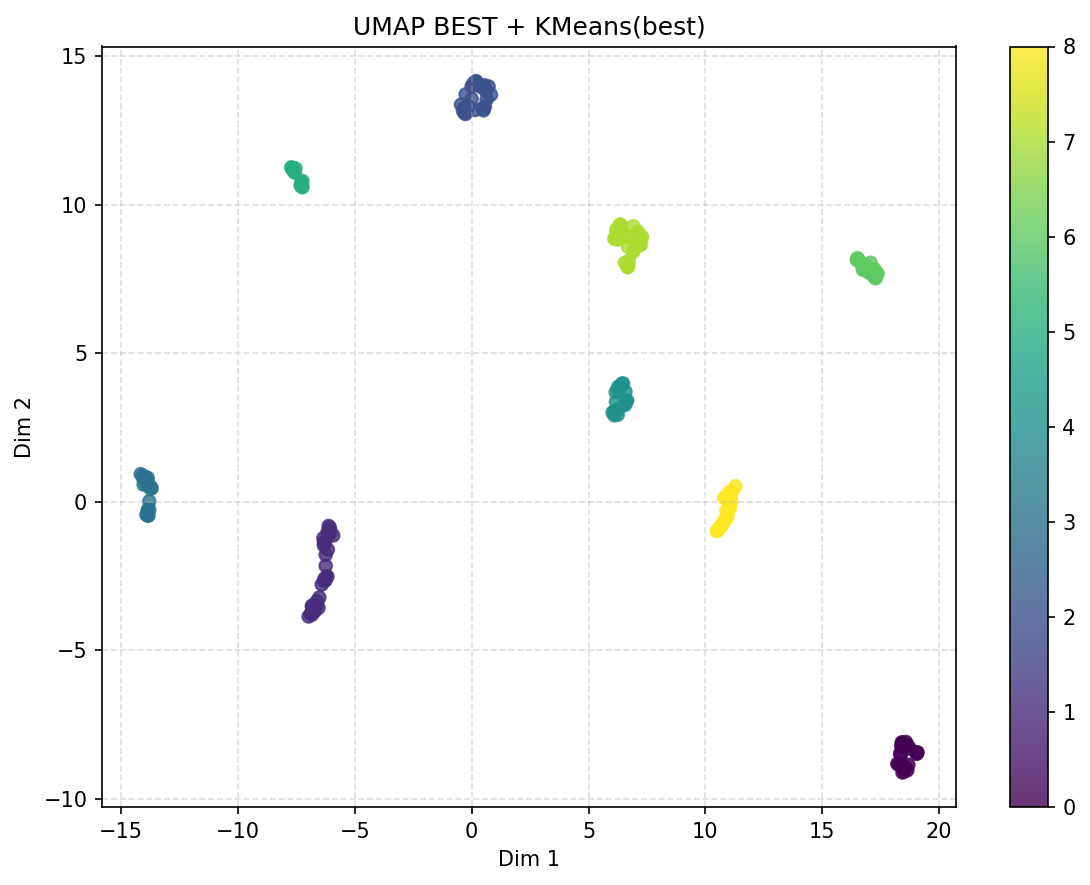

Trustworthiness (n_neighbors=5): 0.9946


0.9945833333333334

In [42]:
# 21.3 UMAP "mejor" + análisis
best_umap = tabla_umap.iloc[0].to_dict()

res_umap_best = m.umap(
    n_neighbors=int(best_umap["n_neighbors"]),
    min_dist=float(best_umap["min_dist"]),
    metric=str(best_umap["metric"]),
)
m.plotEmbedding(res_umap_best["embedding"], hue="cluster_kmeans_best", titulo="UMAP BEST + KMeans(best)")
m.evaluarTrustworthiness(res_umap_best["embedding"])

**Qué se hizo / qué se vio**
- Se corrió UMAP con la mejor configuración encontrada.
- El embedding “BEST” queda como evidencia final para el inciso de UMAP.